<a href="https://colab.research.google.com/github/MonaKhadija/colab-git-assignment2-kb/blob/main/Lesson_6_ml_basic_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Assignment 6: House Price Prediction Using California Housing Data**

Student name: Khadija Bassiouni

## **Assignment Simple machine Learning Project cycle**

### **_House Price Prediction Using California Housing Data_**
This dataset provides information about house prices in California. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "California Housing Dataset" from sklearn.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (California Housing):
* MedInc: Median income in block group
* HouseAge: Median house age in block group
* AveRooms: Average number of rooms per household
* AveBedrms: Average number of bedrooms per household
* Population: Block group population
* AveOccup: Average number of household members
* Latitude: Block group latitude
* Longitude: Block group longitude
* MedHouseVal (Target): Median house value in block group




In [1]:
# --- Imports ---
# Import all the necessary libraries for data handling, visualization, and model building.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# --- Data Collection and Loading ---
# Fetch dataset as frame directly to construct df seamlessly
california = fetch_california_housing(as_frame=True)
df = california.frame

# Verify Target Name column matches expectations
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
# --- Quick Check of Data ---
# Display the first few rows
print(df.head())

# data types and statistical properties
df.info()
print(df.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population

Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


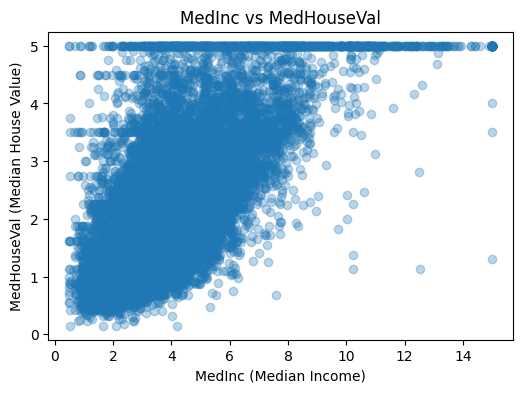

In [4]:
# --- EDA and Data Preprocessing ---
# missing/null values
print("Missing Values:\n", df.isnull().sum())

# scatter plot for MedInc vs Target
plt.figure(figsize=(6, 4))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.3)
plt.xlabel('MedInc (Median Income)')
plt.ylabel('MedHouseVal (Median House Value)')
plt.title('MedInc vs MedHouseVal')
plt.show()

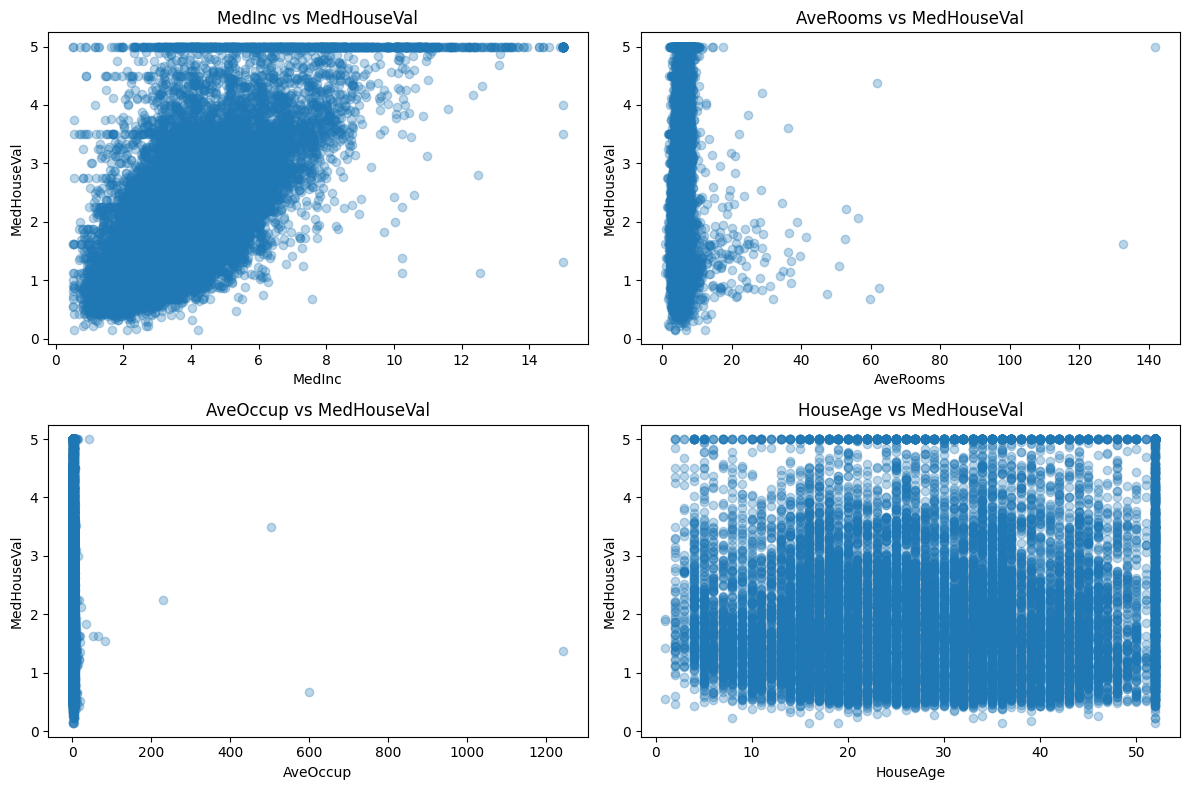

In [5]:
# Function to automate scatter plots for features vs target
def plot_features_vs_target(dataframe, features, target):
    plt.figure(figsize=(12, 8))
    for i, feature in enumerate(features, 1):
        plt.subplot(2, 2, i)
        plt.scatter(dataframe[feature], dataframe[target], alpha=0.3)
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f'{feature} vs {target}')
    plt.tight_layout()
    plt.show()

# Call the function for the selected features
selected_features = ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
plot_features_vs_target(df, selected_features, 'MedHouseVal')

In [6]:
# --- ML Model Training ---
# Separate features (X) and target (y)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Perform 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate and fit the linear model
model = LinearRegression()
model.fit(X_train, y_train)

# --- Model Evaluation ---
# Predict on testing set
y_pred = model.predict(X_test)

# Calculate RMSE and R2 Score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R²): {r2:.4f}")

Root Mean Squared Error (RMSE): 0.7456
R-squared Score (R²): 0.5758


In [7]:
# --- Model Prediction ---
# Creating input dictionary matching feature order
new_data = pd.DataFrame([{
    'MedInc': 3.0,
    'HouseAge': 30.0,
    'AveRooms': 6.0,
    'AveBedrms': 1.0,
    'Population': 1500.0,
    'AveOccup': 3.0,
    'Latitude': 34.0,
    'Longitude': -118.0
}])

# Predict target value
predicted_val = model.predict(new_data)
print(f"Predicted Median House Value: ${predicted_val[0] * 100000:.2f} ({predicted_val[0]:.4f} in $100k units)")

Predicted Median House Value: $154866.33 (1.5487 in $100k units)
